In [1]:
import kagglehub
kagglehub.competition_download('llm-classification-finetuning')

'/kaggle/input/competitions/llm-classification-finetuning'

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

In [3]:
import re   
import string
import nltk   
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
!unzip /usr/share/nltk_data/corpora/wordnet.zip -d /usr/share/nltk_data/corpora/

Archive:  /usr/share/nltk_data/corpora/wordnet.zip
   creating: /usr/share/nltk_data/corpora/wordnet/
  inflating: /usr/share/nltk_data/corpora/wordnet/lexnames  
  inflating: /usr/share/nltk_data/corpora/wordnet/data.verb  
  inflating: /usr/share/nltk_data/corpora/wordnet/index.adv  
  inflating: /usr/share/nltk_data/corpora/wordnet/adv.exc  
  inflating: /usr/share/nltk_data/corpora/wordnet/index.verb  
  inflating: /usr/share/nltk_data/corpora/wordnet/cntlist.rev  
  inflating: /usr/share/nltk_data/corpora/wordnet/data.adj  
  inflating: /usr/share/nltk_data/corpora/wordnet/index.adj  
  inflating: /usr/share/nltk_data/corpora/wordnet/LICENSE  
  inflating: /usr/share/nltk_data/corpora/wordnet/citation.bib  
  inflating: /usr/share/nltk_data/corpora/wordnet/noun.exc  
  inflating: /usr/share/nltk_data/corpora/wordnet/verb.exc  
  inflating: /usr/share/nltk_data/corpora/wordnet/README  
  inflating: /usr/share/nltk_data/corpora/wordnet/index.sense  
  inflating: /usr/share/nltk_data

In [6]:
train_df = pd.read_csv('/kaggle/input/competitions/llm-classification-finetuning/train.csv')
test = pd.read_csv('/kaggle/input/competitions/llm-classification-finetuning/test.csv')

train_df['train_test'] = 1
test['train_test'] = 0
all_data = pd.concat([train_df,test])

print("Import Data Complete")

Import Data Complete


In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57477 entries, 0 to 57476
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              57477 non-null  int64 
 1   model_a         57477 non-null  object
 2   model_b         57477 non-null  object
 3   prompt          57477 non-null  object
 4   response_a      57477 non-null  object
 5   response_b      57477 non-null  object
 6   winner_model_a  57477 non-null  int64 
 7   winner_model_b  57477 non-null  int64 
 8   winner_tie      57477 non-null  int64 
 9   train_test      57477 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 4.4+ MB


In [8]:
train_df.head()

,id,model_a,model_b,prompt,response_a,response_b,winner_model_a,winner_model_b,winner_tie,train_test
0,30192,gpt-4-1106-preview,gpt-4-0613,"[""Is it morally right to try to have a certain...","[""The question of whether it is morally right ...","[""As an AI, I don't have personal beliefs or o...",1,0,0,1
1,53567,koala-13b,gpt-4-0613,"[""What is the difference between marriage lice...","[""A marriage license is a legal document that ...","[""A marriage license and a marriage certificat...",0,1,0,1
2,65089,gpt-3.5-turbo-0613,mistral-medium,"[""explain function calling. how would you call...","[""Function calling is the process of invoking ...","[""Function calling is the process of invoking ...",0,0,1,1
3,96401,llama-2-13b-chat,mistral-7b-instruct,"[""How can I create a test set for a very rare ...","[""Creating a test set for a very rare category...","[""When building a classifier for a very rare c...",1,0,0,1
4,198779,koala-13b,gpt-3.5-turbo-0314,"[""What is the best way to travel from Tel-Aviv...","[""The best way to travel from Tel Aviv to Jeru...","[""The best way to travel from Tel-Aviv to Jeru...",0,1,0,1


In [9]:
total_id = len(train_df["id"])
total_unique_id = len(train_df["id"].unique())

print("Total number of 'id' duplicates:")
print(total_id - total_unique_id)

Total number of 'id' duplicates:
0


In [10]:
nan_count = train_df.isna().sum().sum()
null_count = train_df.isnull().sum().sum()

print('Number of NaN values:', nan_count)
print('Number of null values:', null_count)

Number of NaN values: 0
Number of null values: 0


In [11]:
total_unique_model_a = len(train_df["model_a"].unique())
total_unique_model_b = len(train_df["model_b"].unique())

print("Total number of 'model_a' and 'model_b' unique values:")
print('model_a =', total_unique_model_a)
print('model_b =', total_unique_model_b)

LLM_a = train_df["model_a"].unique()
LLM_b = train_df["model_b"].unique()
LLM = list(set(LLM_a).intersection(set(LLM_b)))

print("total number of LLMs =", len(LLM))
print('LLMs utilized:', LLM)

Total number of 'model_a' and 'model_b' unique values:
model_a = 64
model_b = 64
total number of LLMs = 64
LLMs utilized: ['claude-2.0', 'chatglm3-6b', 'gpt-4-0125-preview', 'stripedhyena-nous-7b', 'llama-2-7b-chat', 'gpt-4-1106-preview', 'llama-2-70b-chat', 'deepseek-llm-67b-chat', 'dolphin-2.2.1-mistral-7b', 'palm-2', 'openchat-3.5-0106', 'claude-instant-1', 'mistral-7b-instruct-v0.2', 'llama-13b', 'starling-lm-7b-alpha', 'llama2-70b-steerlm-chat', 'pplx-7b-online', 'gpt-4-0314', 'alpaca-13b', 'openhermes-2.5-mistral-7b', 'gpt-4-0613', 'vicuna-7b', 'gpt-3.5-turbo-0125', 'gpt-3.5-turbo-0613', 'gpt-3.5-turbo-0314', 'zephyr-7b-beta', 'chatglm2-6b', 'mistral-medium', 'mpt-30b-chat', 'claude-2.1', 'qwen-14b-chat', 'zephyr-7b-alpha', 'chatglm-6b', 'falcon-180b-chat', 'yi-34b-chat', 'llama-2-13b-chat', 'pplx-70b-online', 'openchat-3.5', 'fastchat-t5-3b', 'RWKV-4-Raven-14B', 'mistral-7b-instruct', 'tulu-2-dpo-70b', 'codellama-34b-instruct', 'nous-hermes-2-mixtral-8x7b-dpo', 'wizardlm-70b', '

In [12]:
total_prompt = len(train_df["prompt"])
total_unique_prompt = len(train_df["prompt"].unique())

print("Total number of 'prompt' duplicates:")
print(total_prompt - total_unique_prompt)

Total number of 'prompt' duplicates:
5743


In [14]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = nltk.word_tokenize(text)
    
    return text

def remove_stopwords(text):
    stop_words = set(stopwords.words('english'))
    text_no_stopwords = [word for word in text if word not in stop_words]

    return text_no_stopwords


def lemmatization(text):
    lemmatizer = nltk.WordNetLemmatizer()
    lemmatizer_text = [lemmatizer.lemmatize(text) for text in text]

    return lemmatizer_text


def clean_text(text):
    text = preprocess_text(text)
    filtered_text = remove_stopwords(text)
    lemmatizer_text = lemmatization(filtered_text)
    clean_text = ' '.join(lemmatizer_text)

    return clean_text

train_df["prompt"] = train_df["prompt"].apply(clean_text)
train_df["response_a"] = train_df["response_a"].apply(clean_text)
train_df["response_b"] = train_df["response_b"].apply(clean_text)


print("Clean Cells with Text Data Complete")

Clean Cells with Text Data Complete


model a: model_a
gpt-4-1106-preview          3678
gpt-3.5-turbo-0613          3553
gpt-4-0613                  3099
claude-2.1                  2859
gpt-4-0314                  2087
                            ... 
falcon-180b-chat             145
openchat-3.5-0106            108
qwen1.5-7b-chat              106
qwen1.5-4b-chat              100
mistral-7b-instruct-v0.2      54
Name: count, Length: 64, dtype: int64
-----
Matplotlib barchart, model a:


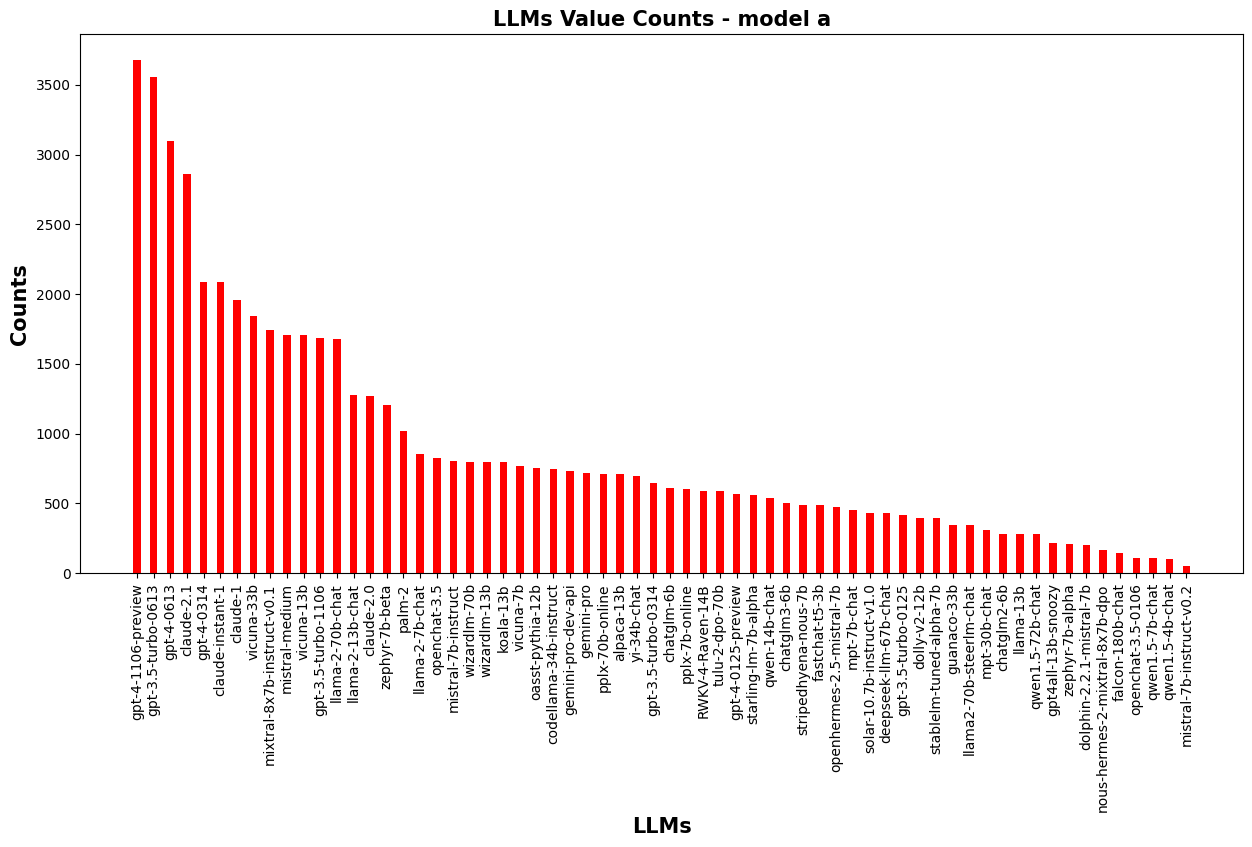

In [16]:
result_model_a = train_df["model_a"].value_counts()
print("model a:", result_model_a)

print("-----")
print("Matplotlib barchart, model a:")
  
barWidth = 0.45
plt.figure(figsize=(15, 7))

plt.bar(result_model_a.index, result_model_a.values, barWidth, color='r')

plt.ylabel('Counts', fontweight ='bold', fontsize = 15)
plt.xlabel('LLMs', fontweight ='bold', fontsize = 15)

plt.xticks(rotation=90)
plt.title('LLMs Value Counts - model a', fontweight ='bold', fontsize = 15)


plt.show()

model b: model_b
gpt-4-1106-preview          3709
gpt-3.5-turbo-0613          3530
gpt-4-0613                  3066
claude-2.1                  2724
claude-instant-1            2051
                            ... 
falcon-180b-chat             141
openchat-3.5-0106            136
qwen1.5-7b-chat              102
qwen1.5-4b-chat              100
mistral-7b-instruct-v0.2      46
Name: count, Length: 64, dtype: int64
-----
Matplotlib barchart, model b:


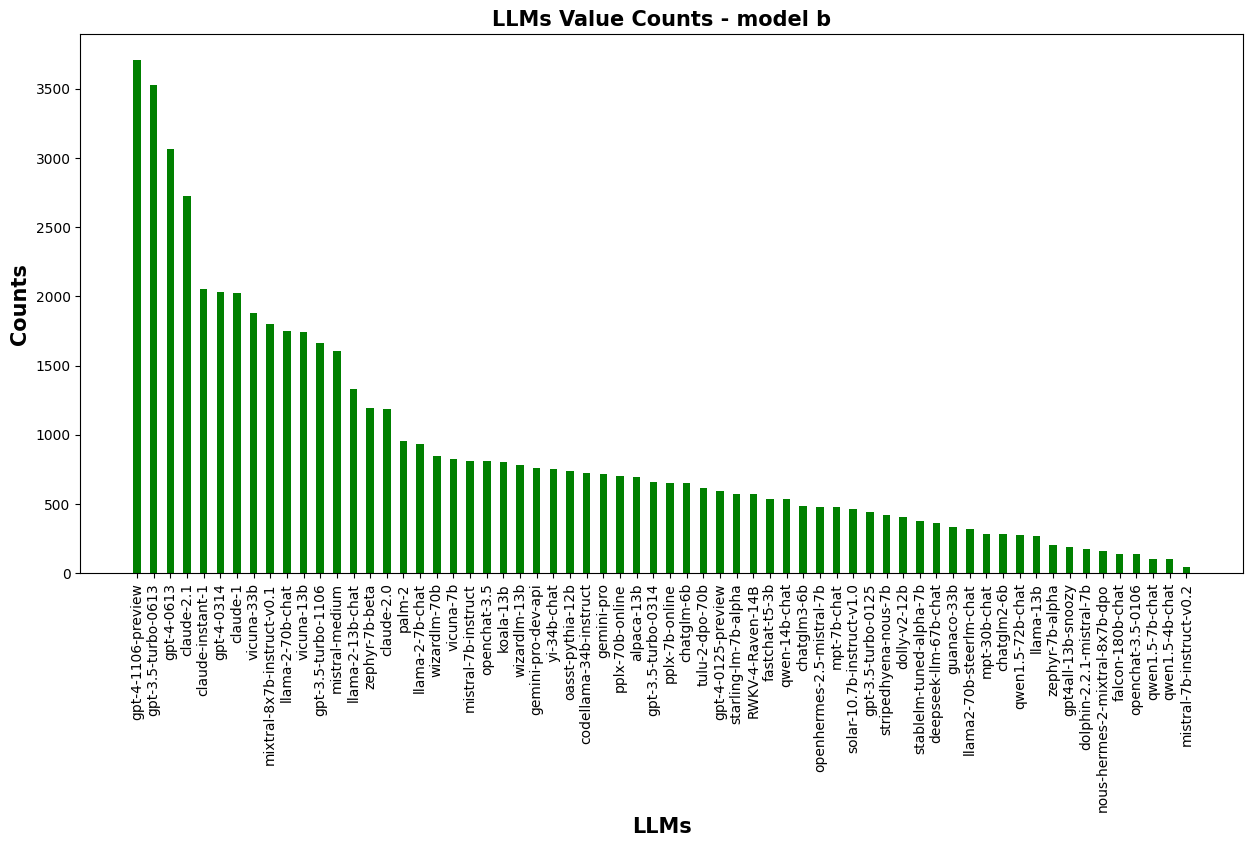

In [17]:
#barchart - model b
result_model_b = train_df["model_b"].value_counts()
print("model b:", result_model_b)

## Matplotlib barchart:
print("-----")
print("Matplotlib barchart, model b:")
  
barWidth = 0.45
plt.figure(figsize=(15, 7))

plt.bar(result_model_b.index, result_model_b.values, barWidth, color='g')

plt.ylabel('Counts', fontweight ='bold', fontsize = 15)
plt.xlabel('LLMs', fontweight ='bold', fontsize = 15)

plt.xticks(rotation=90)
plt.title('LLMs Value Counts - model b', fontweight ='bold', fontsize = 15)


plt.show()

model winner: winner_model
model a       20064
model b       19652
winner tie    17761
Name: count, dtype: int64
-----
Matplotlib barchart, model winner:


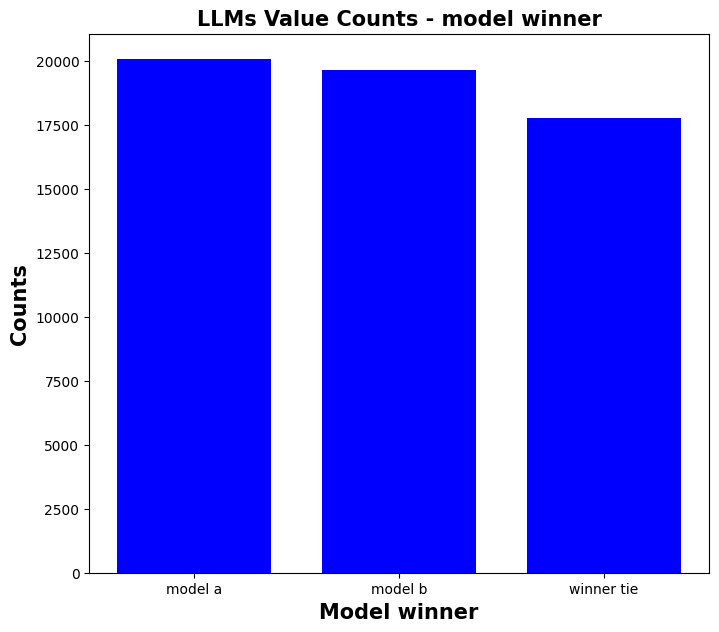

In [19]:
def which_winner(value):
    if  value["winner_model_a"] == 1:
         #winner model a
         value["winner_model_b"] = 0
         value["winner_tie"] = 0
         return 0
    elif value["winner_model_b"] == 1:
         #winner model b
         return 1
    elif value["winner_tie"] == 1:
         #winner tie
         return 2
    return None

train_df["winner"] = train_df.apply(which_winner, axis=1)

train_df["winner_model"] = train_df["winner"].astype(str)
train_df.loc[train_df["winner_model"] == "0", "winner_model"] = "model a"
train_df.loc[train_df["winner_model"] == "1", "winner_model"] = "model b"
train_df.loc[train_df["winner_model"] == "2", "winner_model"] = "winner tie"

result_model_winner = train_df["winner_model"].value_counts()
print("model winner:", result_model_winner)

print("-----")
print("Matplotlib barchart, model winner:")

barWidth = 0.75
plt.figure(figsize=(8, 7))

plt.bar(result_model_winner.index, result_model_winner.values, barWidth, color='b')

plt.ylabel('Counts', fontweight ='bold', fontsize = 15)
plt.xlabel('Model winner', fontweight ='bold', fontsize = 15)

plt.title('LLMs Value Counts - model winner', fontweight ='bold', fontsize = 15)


plt.show()

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features = 150) 
vectorizer_prompt = vectorizer.fit_transform(train_df["prompt"])
print(vectorizer.idf_)
print(vectorizer.get_feature_names_out())
vectorizer_response_a = vectorizer.fit_transform(train_df["response_a"])
print(vectorizer.idf_)
print(vectorizer.get_feature_names_out())
vectorizer_response_b = vectorizer.fit_transform(train_df["response_b"])
print(vectorizer.idf_)
print(vectorizer.get_feature_names_out())



temp_prompt = vectorizer.transform(train_df["prompt"])
temp_response_a = vectorizer.fit_transform(train_df["response_a"])
temp_response_b = vectorizer.fit_transform(train_df["response_b"])

print("vectorizer representation for 'prompt':\n", temp_prompt.toarray())
print("vectorizer representation for 'response a':\n", temp_response_a.toarray())
print("vectorizer representation for 'response b':\n", temp_response_b.toarray())

print("Number of elements for the vectorizer representation for 'prompt':\n", temp_prompt.shape)
print("Number of elements for the vectorizer representation for 'response a':\n", temp_response_a.shape)
print("Number of elements for the vectorizer representation for 'response b':\n", temp_response_b.shape)

[4.96706112 5.08186147 4.89525358 4.79598515 4.27116038 5.00070915
 4.08555976 5.05842688 4.66886466 4.19783836 4.78443324 5.37298589
 5.20805608 5.01314355 4.64860739 4.27253621 4.85337142 5.97019613
 5.19758478 5.08806625 5.15011824 4.26430947 4.27116038 4.58703952
 4.57952539 4.8403313  4.7235384  4.33894277 4.84764543 4.79211967
 4.82905903 4.34435218 3.96418802 5.13152831 4.70710359 4.19401264
 3.89012822 4.91774588 4.57021145 4.85913038 4.26430947 3.76465204
 4.78061206 4.65329751 4.50154826 4.44326846 4.95700159 4.79986564
 5.00356494 4.72642441 5.58583776 5.01410648 4.75426503 5.34711651
 6.36073559 5.23652775 4.30851299 4.74538924 4.99313336 4.87409325
 5.14351755 5.24014439 4.80454219 3.7082764  5.04145194 4.25119601
 4.66478025 4.94524207 5.02476033 3.60307251 4.9790816  4.08062335
 4.96798066 4.78519923 4.61314733 4.80610591 4.54518725 4.23559507
 4.05778019 4.9081681  4.22154126 4.85501345 5.54079261 4.37692835
 4.8599558  3.53957718 5.03454515 5.15454302 5.0199036  4.5343

In [22]:
#selecting the prediction target
train_y = train_df["winner"].values

#choosing "features"
train_X = np.concatenate((temp_prompt.toarray(), temp_response_a.toarray(), temp_response_b.toarray()), axis=1)

print("Selecting The Prediction Target and Choosing Features Complete")

Selecting The Prediction Target and Choosing Features Complete


In [23]:
#use Logistic Regression
from sklearn.linear_model import LogisticRegression
from datetime import datetime

#record start time to calculate the execution time
start = datetime.now()

#Logistic Regression
model = LogisticRegression(max_iter=500, multi_class='multinomial', solver='saga') #For large datasets the “saga” solver is usually faster [scikit-learn documentation]
model.fit(train_X, train_y)

#record end time
end = datetime.now()
 
#calculate the execution time
execution_time = (end - start).total_seconds() / 60
print(f"The time of execution is: {execution_time} minutes")


print("Model Training Complete")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


The time of execution is: 0.36519836666666666 minutes
Model Training Complete


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_score, recall_score

#split into validation and training data
train_X_train, train_X_val, train_y_train, train_y_val = train_test_split(train_X, train_y, test_size=0.2, random_state=42)

#record start time to calculate the execution time
start = datetime.now()

#think about results - comparing predictions (value_y_predict) to the actual winner model (train_y_val)
value_y_predict = model.predict(train_X_val)
print('Model winner prediction', value_y_predict)
print('Model winner real value', train_y_val)

value_y_probabilities = model.predict_proba(train_X_val)
print('Model winner prediction, probability', value_y_probabilities) #winner model a | winner model b | winner tie

#confusion matrix
cm = confusion_matrix(train_y_val, value_y_predict)
print("Confusion Matrix:\n", cm)

#model accuracy
score = model.score(train_X_val, train_y_val)
print('Model Accuracy Score', score)

#macro and micro averaged Precision and Recall
macro_precision = precision_score(train_y_val, value_y_predict, average='macro') #calculate precision for all classes individually and then average them
macro_recall = recall_score(train_y_val, value_y_predict, average='macro')
micro_precision = precision_score(train_y_val, value_y_predict, average='micro') #calculate class wise true positive and false positive and then use that to calculate overall precision
micro_recall = recall_score(train_y_val, value_y_predict, average='micro')
print("Macro Precision:", macro_precision)
print("Macro Recall:", macro_recall)
print("Micro Precision:", micro_precision)
print("Micro Recall:", micro_recall)

#record end time
end = datetime.now()
 
#calculate the execution time
execution_time = (end - start).total_seconds()
print(f"The time of execution is: {execution_time} seconds")

Model winner prediction [1 1 2 ... 0 1 0]
Model winner real value [0 0 2 ... 1 0 0]
Model winner prediction, probability [[0.29130931 0.46865117 0.24003953]
 [0.28374706 0.42614119 0.29011175]
 [0.25444038 0.30181035 0.44374927]
 ...
 [0.3698913  0.36876211 0.26134659]
 [0.32429103 0.34329016 0.3324188 ]
 [0.36409107 0.33345688 0.30245205]]
Confusion Matrix:
 [[2099 1237  694]
 [1316 1937  676]
 [1273 1152 1112]]
Model Accuracy Score 0.44780793319415446
Macro Precision: 0.44784081246026886
Macro Recall: 0.44274505420470317
Micro Precision: 0.44780793319415446
Micro Recall: 0.44780793319415446
The time of execution is: 0.06379 seconds


In [26]:
from sklearn.metrics import log_loss

model_log_loss = log_loss(train_y_val, value_y_probabilities)

print('Model Log loss:', model_log_loss) 


Model Log loss: 1.0549478159166767


In [27]:
test["prompt"] = test["prompt"].apply(clean_text)
test["response_a"] = test["response_a"].apply(clean_text)
test["response_b"] = test["response_b"].apply(clean_text)


print("Clean Cells with Text Data Complete")

Clean Cells with Text Data Complete


In [28]:
#transform text data into numerical form

vectorizer = TfidfVectorizer(max_features = 150)
vectorizer_prompt = vectorizer.fit_transform(test["prompt"])
print(vectorizer.idf_)
print(vectorizer.get_feature_names_out())
vectorizer_test_response_a = vectorizer.fit_transform(test["response_a"])
print(vectorizer.idf_)
print(vectorizer.get_feature_names_out())
vectorizer_test_response_b = vectorizer.fit_transform(test["response_b"])
print(vectorizer.idf_)
print(vectorizer.get_feature_names_out())



temp_test_prompt = vectorizer.transform(test["prompt"])
temp_test_response_a = vectorizer.fit_transform(test["response_a"])
temp_test_response_b = vectorizer.fit_transform(test["response_b"])

print("vectorizer representation for 'prompt':\n", temp_test_prompt.toarray())
print("vectorizer representation for 'response a':\n", temp_test_response_a.toarray())
print("vectorizer representation for 'response b':\n", temp_test_response_b.toarray())

print("Number of elements for the vectorizer representation for 'prompt':\n", temp_test_prompt.shape)
print("Number of elements for the vectorizer representation for 'response a':\n", temp_test_response_a.shape)
print("Number of elements for the vectorizer representation for 'response b':\n", temp_test_response_b.shape)

[1.69314718 1.69314718 1.69314718 1.69314718 1.69314718 1.69314718
 1.69314718 1.69314718 1.69314718 1.69314718 1.69314718 1.69314718
 1.69314718 1.69314718 1.69314718 1.69314718 1.69314718 1.69314718
 1.69314718 1.69314718 1.69314718 1.69314718 1.69314718 1.69314718
 1.69314718 1.69314718 1.69314718 1.69314718 1.69314718 1.69314718
 1.69314718 1.69314718 1.69314718 1.69314718 1.69314718 1.69314718
 1.69314718 1.69314718 1.69314718 1.69314718 1.69314718 1.69314718
 1.69314718 1.69314718 1.69314718 1.69314718 1.69314718 1.69314718
 1.69314718 1.69314718 1.69314718 1.69314718 1.69314718 1.69314718
 1.69314718 1.69314718 1.69314718 1.69314718 1.69314718 1.69314718
 1.69314718 1.69314718 1.69314718 1.69314718]
['adult' 'anybody' 'anything' 'ate' 'belief' 'blue' 'care'
 'classification' 'debate' 'definition' 'dont' 'example' 'extremely'
 'female' 'find' 'finetune' 'finetuning' 'fluid' 'full' 'gamete' 'gender'
 'get' 'goddy' 'ground' 'head' 'heated' 'hehim' 'helping' 'human' 'hung'
 'imagene

In [29]:
test_X = np.concatenate((temp_test_prompt.toarray(), temp_test_response_a.toarray(), temp_test_response_b.toarray()), axis=1)
value_test_y_probabilities = model.predict_proba(test_X)
print('Model winner prediction, probability', value_test_y_probabilities) #winner model a | winner model b | winner tie

Model winner prediction, probability [[0.15398568 0.44576357 0.40025075]
 [0.33351431 0.34474833 0.32173736]
 [0.42008545 0.40353486 0.17637969]]
